In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import os, sys, h5py
import pandas as pd
import astropy.units as u

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

import cobaya
import getdist.plots as gdplt
from getdist import loadMCSamples
%matplotlib inline

from cobaya.samplers.mcmc import plot_progress
from cobaya.yaml import yaml_load_file
from cobaya.run import run
from cobaya import load_samples

In [4]:
from pathlib import Path
from datetime import datetime

In [5]:
Path("runs") / datetime.now().strftime("%Y%m%d_%H%M%S")

PosixPath('runs/20260709_080944')

# Before running the chains

In [2]:
# Check to see if you can import the likelihoods

from Models import TargetData, MapData, HaloModels, FFTs, Projections, Profiles, SHMRs, HODs, Dust, Measurements, Plots, Studies, Spectra2
import Models.Studies as Studies
import Models.HODs as HODs
import Models.HaloModels as HaloModels
import SOLikelihoods

2026-07-09 07:52:03.923086: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-09 07:52:03.923199: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-09 07:52:04.012246: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-09 07:52:04.199532: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-09 07:52:07.097490: W tensorflow/compiler/tf2

In [ ]:
# updated_info_minimizer, minimizer = cobaya.run("/global/homes/c/cpopik/CAPPIBARAS/chains/runchainsLiu.yaml", force=True)
# yaml_file = "/global/homes/c/cpopik/CAPPIBARAS/chains/runchainsLiu.yaml"

# yaml_info = cobaya.yaml.yaml_load_file(yaml_file)
# for key in yaml_info['likelihood'].keys():
#     yaml_info['likelihood'][key]['yaml_file'] = yaml_file

# # Run a quick minimizer but change the output file so it doesn't overwrite the real one
# yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()  # make copy of yaml
# yamlinfo_min["output"] = yamlinfo_min["output"] + "_minimizer"  # only change the output location
# updated_info_minimizer_quick, minimizer_quick = cobaya.run(yamlinfo_min, minimize=True, force=True)  # run that with the quick minimizer

# parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}  # get best fit parameter values

# # edit the ref guess values using the minimizer
# yamlinfo = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE)
# minimum = minimizer_quick.products()["minimum"]
# for pars in 

### Run Model and put in guesses

In [39]:
# Reload modules to updates
importlib.reload(SOLikelihoods); importlib.reload(Projections); importlib.reload(HaloModels); importlib.reload(TargetData); importlib.reload(MapData); importlib.reload(Profiles); importlib.reload(Measurements); importlib.reload(Studies); importlib.reload(Spectra2); importlib.reload(HODs)

# Define YAML file and print steps
SOLikelihoods.YAML_FILE  = "/global/homes/c/cpopik/CAPPIBARAS/runs/runchains_final.yaml"
SOLikelihoods.VERBOSE = True
likelis = cobaya.get_model(SOLikelihoods.YAML_FILE).likelihood

guesses = []
for likeli in likelis.values():
    guesses.append({
        'chi2overN': -2*likeli.logp()/len(likeli.data.x),
        'tot': likeli.model({}),
        '1h': likeli.project(likeli.avemeth(likeli.prof1h({}))),
        '2h': likeli.project(likeli.avemeth(likeli.prof2h({})))})

[model] *WARNING* Ignored blocks/options: ['shared', 'sampler', 'output', 'output_options']


Loading in Fixed Parameters and Data/Model Dictionaries from yaml file
Loading and Initializing Halo Model: pyccl_model {'MassDef': '200c', 'MassFunc': 'Tinker08', 'HaloBias': 'Tinker10', 'PowSpec': 'Linear', 'Concentration': 'Bhattacharya13'}
Loading in Measurement Data: RiedGuachalla2025 {'bin': 'z_1'}
Loading in Map Data: Coulton2024 {}
Loading in Target Data: RiedGuachalla2025 {'bin': 'z_1'}
Making Redshift and Halo Mass Distributions:
Setting up Projection, Beam Convolution, Aperture methods: Popik2025 {}
Setting up Profile Model Popik2026 {}
Setting up Basic Average
Setting up HOD Average
HOD Model: logMhMean=12.94
Setting up Data
Setting up Profile Model
1.00e-03 Mpc<r<1.38e+02 Mpc, N_r=100


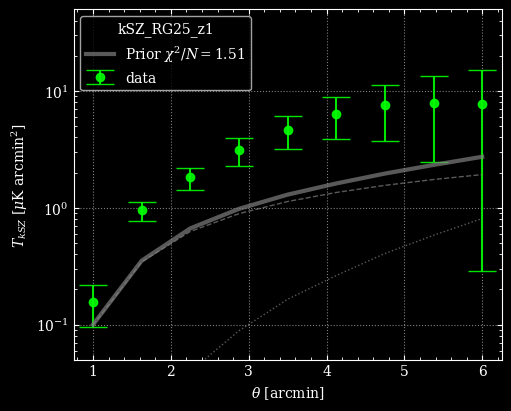

In [49]:
nrows = int(np.ceil(len(likelis)/2))
height = 4*np.ceil(len(likelis)/2)
ncols = 2 if len(likelis)>1 else 1
width = 10 if len(likelis)>1 else 5
fix, axs = plt.subplots(nrows, ncols, figsize=(width, height), layout='constrained')

for ax, likeli, guess in zip(axs.flatten() if len(likelis)>1 else [axs], likelis.values(), guesses):
    # Plot actual data and errors
    ax.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='lime', marker='o', capsize=10, ls='None', alpha=0.9)

    # Plot original guesses based off yaml file
    ax.plot(likeli.data.x, guess['tot'], lw=3, label=rf"Prior $\chi^2/N=${guess['chi2overN']:.2f}", c='gray',alpha=0.7)
    ax.plot(likeli.data.x, guess['1h'], ls='--',lw=1, c='gray',alpha=0.7)
    ax.plot(likeli.data.x, guess['2h'], ls=':', lw=1, c='gray',alpha=0.7)
        
    ax.legend(title=likeli.get_name())
    if "kSZ" in likeli.get_name():
        ax.set(yscale='log', ylim=(5e-2, 5e1), ylabel=r'$T_{kSZ} \ [\mu \text{K} \ \text{arcmin}^2]$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in likeli.get_name():
        ax.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')

plt.show()

### Do a quick minimizer run

In [132]:
importlib.reload(SOLikelihoods)
SOLikelihoods.YAML_FILE = "/global/homes/c/cpopik/CAPPIBARAS/runs/runchains_final.yaml"
SOLikelihoods.VERBOSE = False

# Run a quick minimizer but change the output file so it doesn't overwrite the real one
yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()
yamlinfo_min["output"] = yamlinfo_min["output"] + "_quick_minimizer"
yamlinfo_min["sampler"]["minimize"] = {'method':'Nelder-Mead', 'ignore_prior': True}
updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, minimize=True, force=True)

parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

minimizerfits = []
for likeli in likelis.values():
    minimizerfits.append({
        'chi2overN': -2*likeli.logp(**parsfit)/len(likeli.data.x),
        'tot': likeli.model(parsfit),
        '1h': likeli.project(likeli.avemeth(likeli.prof1h(parsfit))),
        '2h': likeli.project(likeli.avemeth(likeli.prof2h(parsfit)))})

INFO:output:Output to be read-from/written-into folder 'runs/Semifinal', with prefix 'testing_theory_3_quick_minimizer'


[output] Output to be read-from/written-into folder 'runs/Semifinal', with prefix 'testing_theory_3_quick_minimizer'


INFO:output:Found existing info files with the requested output prefix: 'runs/Semifinal/testing_theory_3_quick_minimizer'


[output] Found existing info files with the requested output prefix: 'runs/Semifinal/testing_theory_3_quick_minimizer'


INFO:output:Will delete previous products ('force' was requested).


...

[minimize] -log(posterior) minimized to 11.9942


INFO:minimize:Parameter values at minimum:
   weight  minuslogpost   logrho0    beta_k      xc_k     A2h_k  minuslogprior  minuslogprior__0      chi2  chi2__kSZ_RG25_z1
0     1.0      11.99421  2.955738  2.920047  0.595708  4.991817       8.111578          8.111578  7.765264           7.765264


[minimize] Parameter values at minimum:
   weight  minuslogpost   logrho0    beta_k      xc_k     A2h_k  minuslogprior  minuslogprior__0      chi2  chi2__kSZ_RG25_z1
0     1.0      11.99421  2.955738  2.920047  0.595708  4.991817       8.111578          8.111578  7.765264           7.765264


INFO:minimize:Full set of minima:
{'0': (11.994209661265117, True), '1': (11.994209661265117, True)}


[minimize] Full set of minima:
{'0': (11.994209661265117, True), '1': (11.994209661265117, True)}


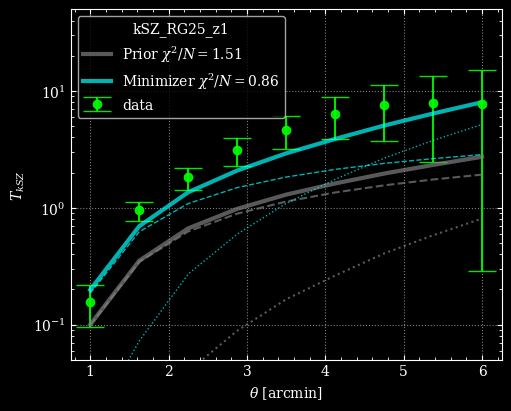

In [133]:
nrows = int(np.ceil(len(likelis)/2))
height = 4*np.ceil(len(likelis)/2)
ncols = 2 if len(likelis)>1 else 1
width = 10 if len(likelis)>1 else 5
fix, axs = plt.subplots(nrows, ncols, figsize=(width, height), layout='constrained')

for ax, likeli, guess, minfit in zip(axs.flatten() if len(likelis)>1 else [axs], likelis.values(), guesses, minimizerfits):
    # Plot actual data and errors
    ax.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='lime', marker='o', capsize=10, ls='None', alpha=0.9)

    # Plot original guesses based off yaml file
    ax.plot(likeli.data.x, guess['tot'], lw=3, label=rf"Prior $\chi^2/N=${guess['chi2overN']:.2f}", c='gray',alpha=0.7)
    ax.plot(likeli.data.x, guess['1h'], ls='--', c='gray',alpha=0.7)
    ax.plot(likeli.data.x, guess['2h'], ls=':', c='gray',alpha=0.7)
    
    # Plot minimizer results
    ax.plot(likeli.data.x, minfit['tot'], lw=3,label=rf"Minimizer $\chi^2/N=${minfit['chi2overN']:.2f}", c='cyan',alpha=0.7)
    ax.plot(likeli.data.x, minfit['1h'], ls='--',lw=1, c='cyan',alpha=0.7)
    ax.plot(likeli.data.x, minfit['2h'], ls=':', lw=1, c='cyan',alpha=0.7)
        
    ax.legend(title=likeli.get_name())
    if "kSZ" in likeli.get_name():
        ax.set(yscale='log', ylim=(5e-2, 5e1), ylabel=r'$T_{kSZ}$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in likeli.get_name():
        ax.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')

plt.show()

In [79]:
parsref = {k: v['ref'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}
parspriof = {k: v['prior'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

pd.DataFrame([parspriof, parsref, parsfit], index=["Prior", "Ref", "Minimizer Fit"])

,logrho0,beta_k,xc_k,A2h_k
Prior,"{'min': 0.5, 'max': 20}","{'min': 1.5, 'max': 6}","{'min': 0.1, 'max': 2}","{'min': 0.01, 'max': 20}"
Ref,3,3.5,0.6,5
Minimizer Fit,2.955738,2.920047,0.595708,4.991817


# While running chains

INFO:samplecollection:Loaded 12013 sample points from '/global/homes/c/cpopik/CAPPIBARAS/runs/Semifinal/testing_theory_3.1.txt'


[samplecollection] Loaded 12013 sample points from '/global/homes/c/cpopik/CAPPIBARAS/runs/Semifinal/testing_theory_3.1.txt'


[tools] *WARNING* Last row of /global/homes/c/cpopik/CAPPIBARAS/runs/Semifinal/testing_theory_3.progress is incomplete or contains NaNs


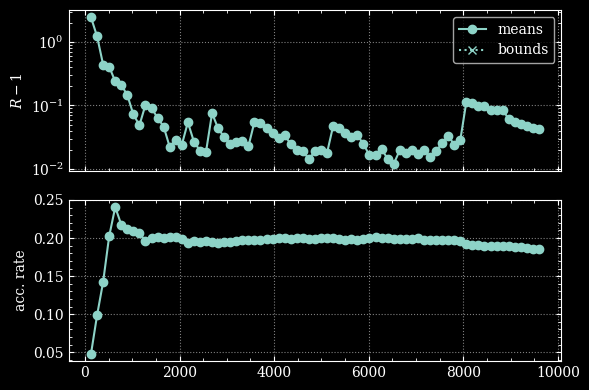

In [ ]:
import yaml
# filename = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE)["output"]
filename = "/global/homes/c/cpopik/CAPPIBARAS/runs/Semifinal/testing_theory_3"

with open(filename + ".input.yaml", "r") as f:
    yaml_load = yaml.safe_load(f)

folder,name = os.path.split(os.path.abspath(filename))
plot_progress(filename, figure_kwargs={"figsize": (6,4)})

plt.tight_layout()
plt.show()

In [ ]:
# Export the results to GetDist
gd_sample = load_samples(filename, to_getdist=True)

# Analyze and plot
mean = gd_sample.getMeans()[:-2]
err = np.diag(gd_sample.getCovMat().matrix)**0.5

INFO:samplecollection:Loaded 12013 sample points from '/global/homes/c/cpopik/CAPPIBARAS/runs/Semifinal/testing_theory_3.1.txt'


[samplecollection] Loaded 12013 sample points from '/global/homes/c/cpopik/CAPPIBARAS/runs/Semifinal/testing_theory_3.1.txt'


In [127]:
Path("runs") / datetime.now().strftime("%Y-%m-%d_%H-%M")

PosixPath('runs/2026-07-09_10-22')

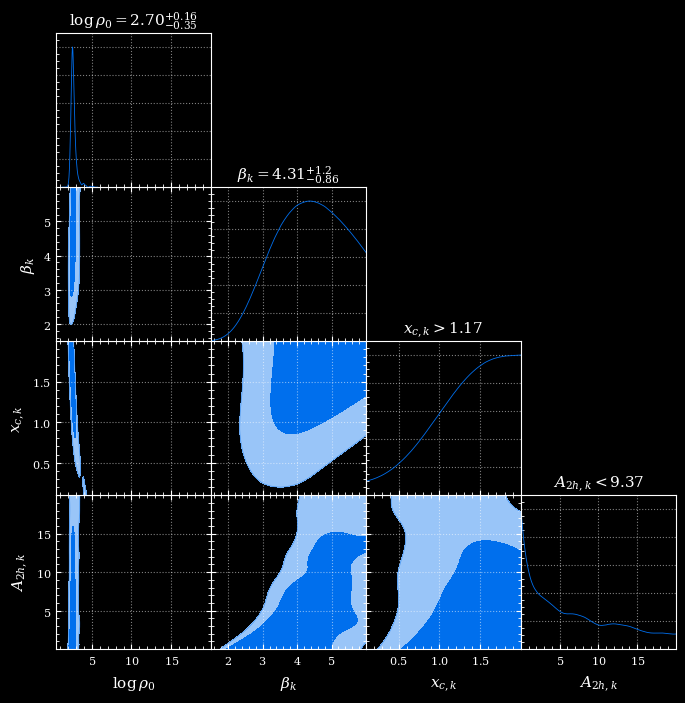

In [120]:
# Export the results to GetDist
folder,name = os.path.split(os.path.abspath(filename))

pnames = {k: v['prior'] for k, v in yaml_load["params"].items() if 'prior' in v}

gdplot = gdplt.get_subplot_plotter(chain_dir=folder)
gdplot.settings.title_limit_fontsize=14
gdplot.triangle_plot(
    gd_sample, list(pnames.keys()), filled=True, title_fmt='latex', title_limit=1,
    param_limits={k: (v['min'], v['max']) for k, v in pnames.items()})

# After

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].loglog(model.r, model.aveprof(p0), ls='--', lw=5,label='model guess')
axs[0].loglog(model.r, model.aveprof(parsfit), ls='--', lw=5,label='model quick fit')
axs[0].loglog(model.r, model.aveprof(mean), ls='--', lw=5,label='model fit')
axs[0].set(
    xlabel=r"$r$"+f" [{model.r.unit.to_string(format='latex')}]", ylabel=r"$\rho_\text{gas}$"+f" [{model.aveprof(p0).unit.to_string(format='latex')}]")

axs[1].set(
    xlabel=r"$R$"+f" [{model.meas.R.unit.to_string(format='latex')}]", ylabel=r"$T_\text{kSZ}$"+f" [{model.meas.TkSZ_data.unit.to_string(format='latex')}]",
    yscale='log')
axs[1].errorbar(model.meas.R, model.meas.TkSZ_data, model.meas.TkSZ_err,label='meas data', c='lime', marker='o', capsize=10, ls='None')
axs[1].plot(model.meas.R, model._get_theory(p0), ls='--', lw=5,label='model guess')
axs[1].plot(model.meas.R, model._get_theory(parsfit), ls='--', lw=5,label='model quick fit')
axs[1].plot(model.meas.R, model._get_theory(mean), ls='--', lw=5,label='model fit')

axs[1].legend()
plt.show()

## Plot the results of that 

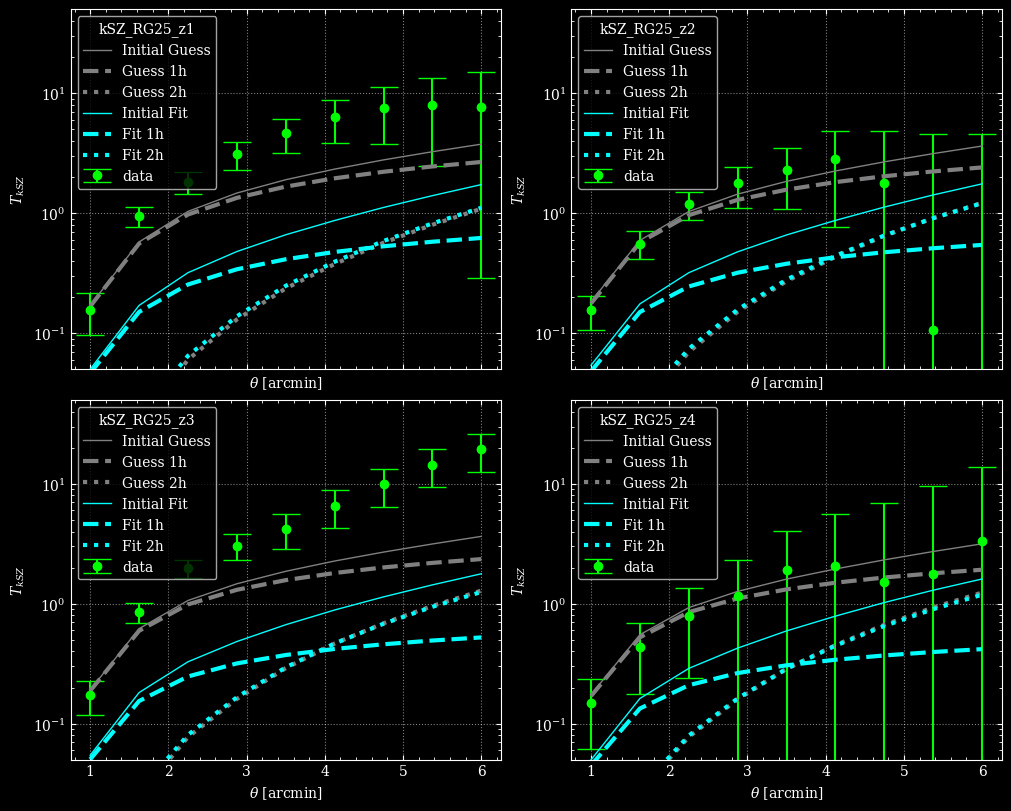

In [16]:
parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

fix, axs = plt.subplots(int(np.ceil(len(likelis)/2)), 2, figsize=(10, 4*np.ceil(len(likelis)/2)), layout='constrained', sharex=True)

for ax, likeli in zip(axs.flatten(), likelis.values()):
    ax.errorbar(likeli.data.x, likeli.data.y, np.diag(likeli.data.cov)**0.5, label='data', c='lime', marker='o', capsize=10, ls='None')
    fit = likeli.model(parsfit)
    fit1h = likeli.project(likeli.ave_hod(likeli.prof1h(parsfit)))
    fit2h = likeli.project(likeli.ave_hod(likeli.prof2h(parsfit)))
    
    guess = likeli.model({})
    guess1h = likeli.project(likeli.ave_hod(likeli.prof1h({})))
    guess2h = likeli.project(likeli.ave_hod(likeli.prof2h({})))

    ax.plot(likeli.data.x, guess, lw=1, label='Initial Guess', c='gray')
    ax.plot(likeli.data.x, guess1h, ls='--',lw=3,label='Guess 1h', c='gray')
    ax.plot(likeli.data.x, guess2h, ls=':', lw=3,label='Guess 2h', c='gray')
    
    ax.plot(likeli.data.x, fit, lw=1, label='Initial Fit', c='cyan')
    ax.plot(likeli.data.x, fit1h, ls='--',lw=3,label='Fit 1h', c='cyan')
    ax.plot(likeli.data.x, fit2h, ls=':', lw=3,label='Fit 2h', c='cyan')

    if "kSZ" in likeli.get_name():
        ax.set(yscale='log', ylim=(5e-2, 5e1), ylabel=r'$T_{kSZ}$', xlabel=r'$\theta$ [arcmin]')
    elif "tSZ" in likeli.get_name():
        ax.set(ylim=(-0.5e-6, 6e-6), ylabel=r'$y$', xlabel=r'$\theta$ [arcmin]')
    ax.legend(title=likeli.get_name())

plt.show()

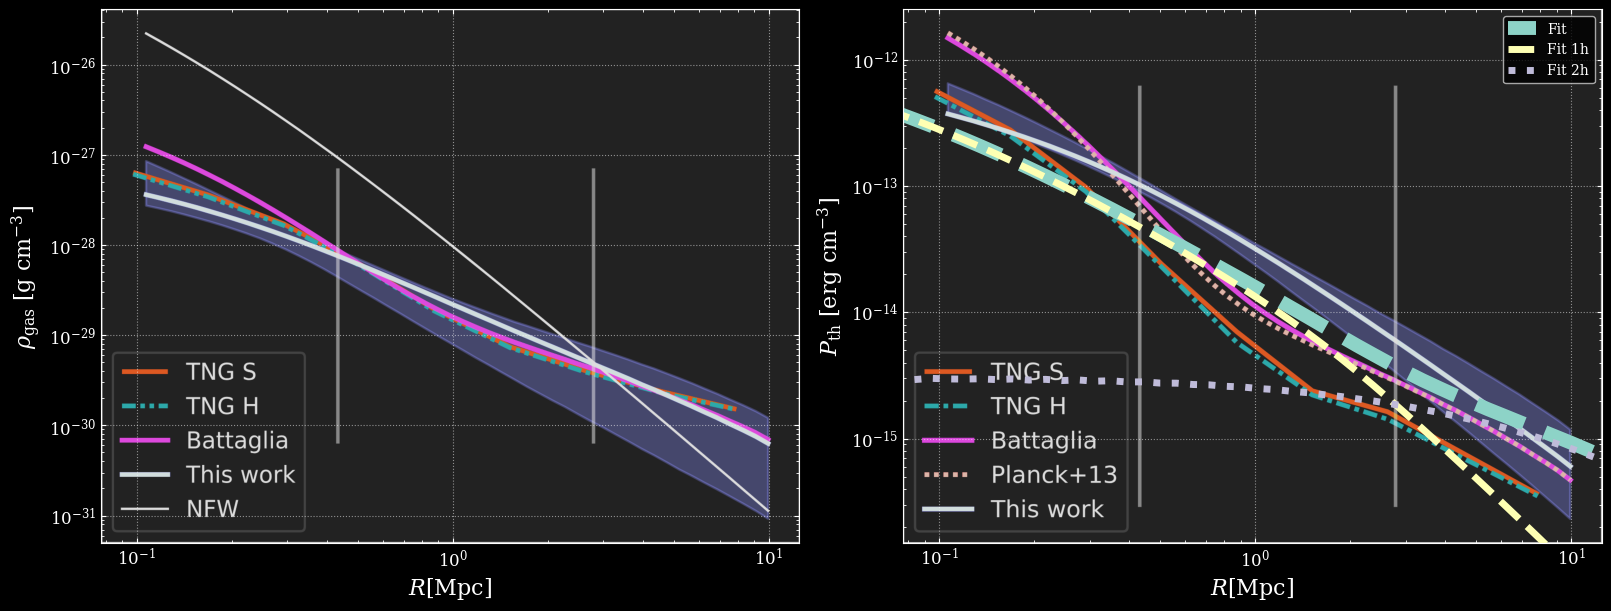

In [37]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Amodeo2021().Fig6_row1()

unitsto = u.erg/u.cm**3

for ax, mod in zip(axs, ['asd', likeli]):
    # Plot random z and logM
    if mod=='asd': pass
    else:
        zind, logMind = np.argmin(np.abs(mod.targetdata.z - 0.5)), np.argmin(np.abs(mod.targetdata.logMh - 13.3))
        zmlabel = f'z={mod.targetdata.z[zind]:.2f}, logM={mod.targetdata.logMh[logMind]:.2f}'
        # ax.loglog(mod.r, mod.prof()[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)
        # ax.loglog(mod.r, mod.prof2h()[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)

        # Plot HOD average profile
        ax.loglog(mod.r, mod.ave_hod(mod.prof(parsfit)).cgs, ls='--', lw=10, label='Fit')
        ax.loglog(mod.r, mod.ave_hod(mod.prof1h(parsfit)).cgs, ls='--', lw=5, label='Fit 1h')
        ax.loglog(mod.r, mod.ave_hod(mod.prof2h(parsfit)).cgs, ls=':', lw=5, label='Fit 2h')
        
        # ax.loglog(mod.r, mod.prof({})[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)
        # ax.loglog(mod.r, mod.prof2h()[:, zind, logMind].cgs, ls='--', lw=10, label=zmlabel)

        ax.legend()
plt.show()

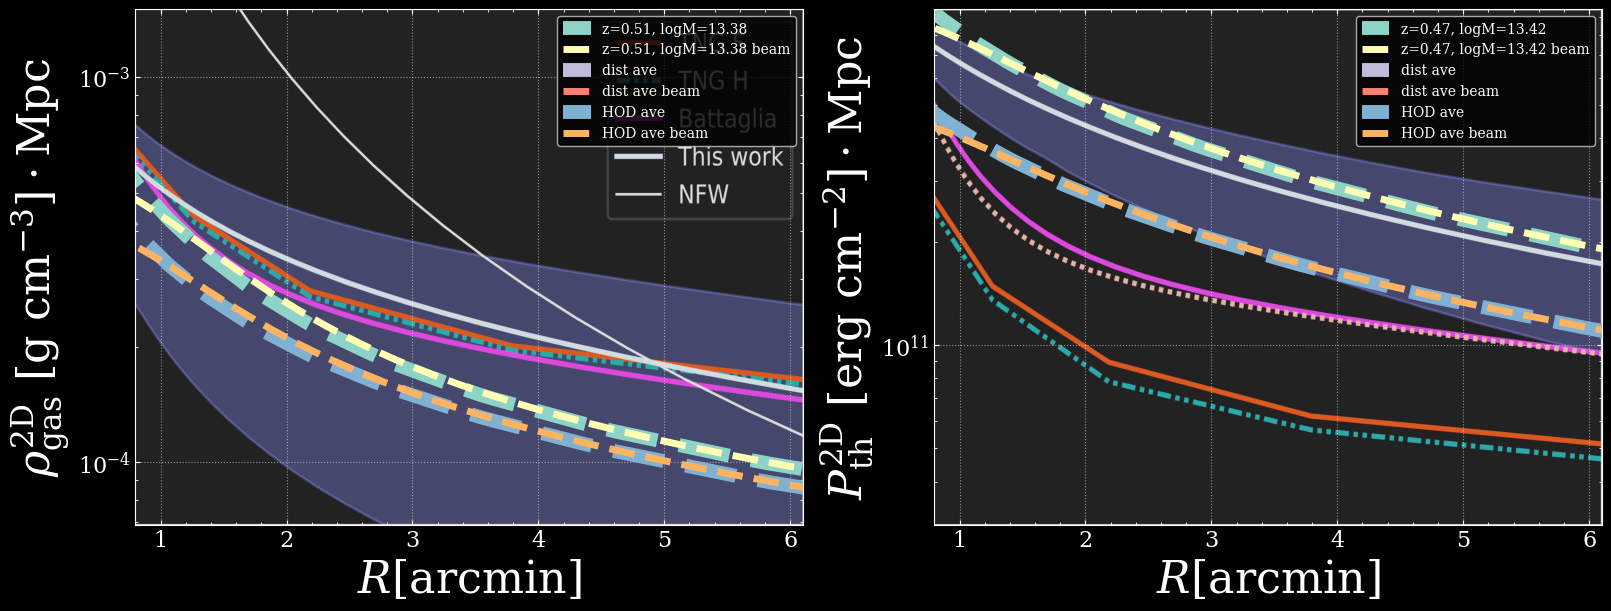

In [124]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Amodeo2021().Fig6_row2()

for ax, mod in zip(axs, [kSZ, tSZ]):
    Rs = (mod.proj.rht.r*u.rad).to(u.arcmin)
    
    zind, logMind = np.argmin(np.abs(mod.targetdata.z - mod.targetdata.zMean)), np.argmin(np.abs(mod.targetdata.logMh - mod.targetdata.logMhMean))
    zmlabel = f'z={mod.targetdata.z[zind]:.2f}, logM={mod.targetdata.logMh[logMind]:.2f}'

    prof2D = mod.proj2D(mod.prof()[:, zind, logMind])
    ax.plot(Rs, prof2D.cgs, ls='--', lw=10, label=zmlabel)
    Rbeam, prof2Dbeam = mod.beamconvolve(prof2D)
    ax.plot(Rbeam, prof2Dbeam.cgs, ls='--', lw=5, label=f'{zmlabel} beam')

    profdistave2D = mod.proj2D(mod.ave_smf(mod.prof()))
    ax.plot(Rs, profdistave2D, ls='--', lw=10, label='dist ave')
    Rbeam, prof2Dbeam = mod.beamconvolve(profdistave2D)
    ax.plot(Rbeam, prof2Dbeam, ls='--', lw=5, label=f'dist ave beam')

    profhodave2D = mod.proj2D(mod.ave_hod(mod.prof()))
    ax.plot(Rs, profhodave2D.cgs, ls='--', lw=10, label='HOD ave')
    Rbeam, prof2Dbeam = mod.beamconvolve(profhodave2D)
    ax.plot(Rbeam, prof2Dbeam.cgs, ls='--', lw=5, label=f'HOD ave beam')

    ax.legend()

plt.show()

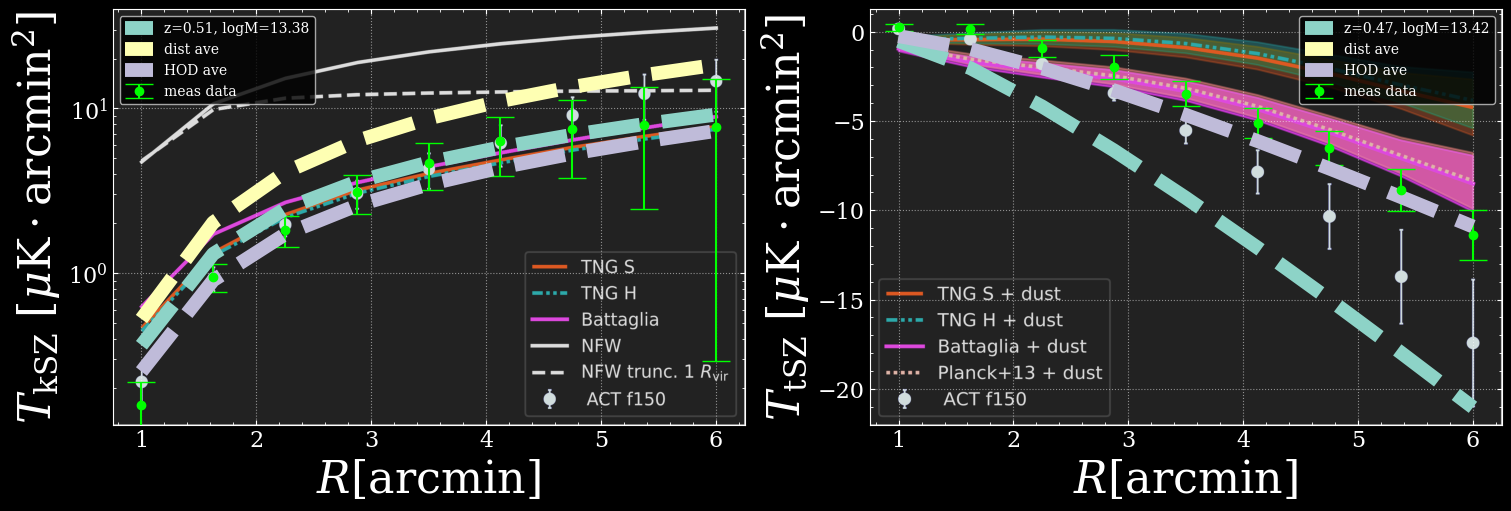

In [ ]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = Plots.Amodeo2021().Fig6_row3()

convs = [1, tSZ.halomodel.y_to_uK(150*u.GHz)]

axs[0].errorbar(kSZ.meas.R, kSZ.meas.TkSZ_data, kSZ.meas.TkSZ_err,label='meas data', c='lime', marker='o', capsize=10, ls='None')
axs[1].errorbar(tSZ.meas.R, tSZ.meas.y_data*convs[1], -tSZ.meas.y_err*convs[1],label='meas data', c='lime', marker='o', capsize=10, ls='None')

for ax, mod, conv in zip(axs, [kSZ, tSZ], convs):
    zind, logMind = np.argmin(np.abs(mod.targetdata.z - mod.targetdata.zMean)), np.argmin(np.abs(mod.targetdata.logMh - mod.targetdata.logMhMean))
    zmlabel = f'z={mod.targetdata.z[zind]:.2f}, logM={mod.targetdata.logMh[logMind]:.2f}'

    modprof = mod.project(mod.prof()[:, zind, logMind])
    ax.plot(mod.meas.R, modprof*conv, ls='--', lw=10,label=zmlabel)

    ax.plot(mod.meas.R, mod.project(mod.ave_smf(mod.prof()))*conv, ls='--', lw=10, label='dist ave')
    ax.plot(mod.meas.R, mod.project(mod.ave_hod(mod.prof()))*conv, ls='--', lw=10, label='HOD ave')
    # ax.plot(mod.meas.R, mod.model({})*conv, ls='--', lw=5,label='model final')
    ax.legend()

plt.show()

In [9]:
from scipy.integrate import simpson as simp

logMs = model.targetdata.logM
Ms = 10**logMs
dndlogM = model.targetdata.dndlogM

print(np.log10(np.trapz(Ms*dndlogM, logMs)/np.trapz(dndlogM, logMs)),
      np.log10(simp(Ms*dndlogM, logMs)/simp(dndlogM, logMs)))
print(np.trapz(logMs*dndlogM, logMs)/np.trapz(dndlogM, logMs),
      simp(logMs*dndlogM, logMs)/simp(dndlogM, logMs))

# Cut off long tails
mcut = (logMs>12.5) & (logMs<14.5)
logMs = logMs[mcut]
Ms = Ms[mcut]
dndlogM = dndlogM[mcut]

print(np.log10(np.trapz(Ms*dndlogM, logMs)/np.trapz(dndlogM, logMs)),
      np.log10(simp(Ms*dndlogM, logMs)/simp(dndlogM, logMs)))
print(np.trapz(logMs*dndlogM, logMs)/np.trapz(dndlogM, logMs),
      simp(logMs*dndlogM, logMs)/simp(dndlogM, logMs))

14.005813403232485 14.005611365227328
13.658483318354147 13.658243002277205
13.796032396485485 13.79614588615424
13.602715886961267 13.602825985801275


In [27]:
logM = model.targetdata.logM
zs = model.targetdata.z

# mcut = (logM>12.5) & (logM<14.5)
# logM = logM[mcut]

Nc, Ns = model.hod.Ncen(logM), model.hod.Nsat(logM)
dndlogm = model.halomodel.dndlogm(zs[:, None], logM)  # calculate halo mass function
# dndlogm[:, (logM<12)] = 0
infac = dndlogm*model.targetdata.dNdz[:, None]  # combined mass/z distributions

ngal = lambda p: np.trapz((Nc(p)+Ns(p))*dndlogm, logM)  # total galaxy number
# Hg = lambda p: (Nc(p) + Ns(p))/ngal(p)[:, None]  # HOD cross-spectra function
Hg = lambda p: (Nc(p)[None, None, :] + Ns(p)[None, None, :])/ngal(p)[:, None]  # HOD cross-spectra function
Hg_norm = lambda p: Hg(p)/np.trapz(np.trapz(Hg(p)*infac, logM), zs)  # normalized galaxy distribution
Hg_norm({}).shape
intfac0 = Hg_norm({})*infac  # combine default HOD galaxy dist into integrand factor
intfac = lambda p: Hg_norm(p)*infac if p!={} else intfac0  # recalculate integrand factor if HOD galaxy dist is being fit

print(np.log10(np.trapz(np.trapz(10**logM*intfac0, logM), zs)))  # take mass/redshift average
print(np.trapz(np.trapz(logM*intfac0, logM), zs))  # take mass/redshift average

[13.39401814]
[13.00696436]


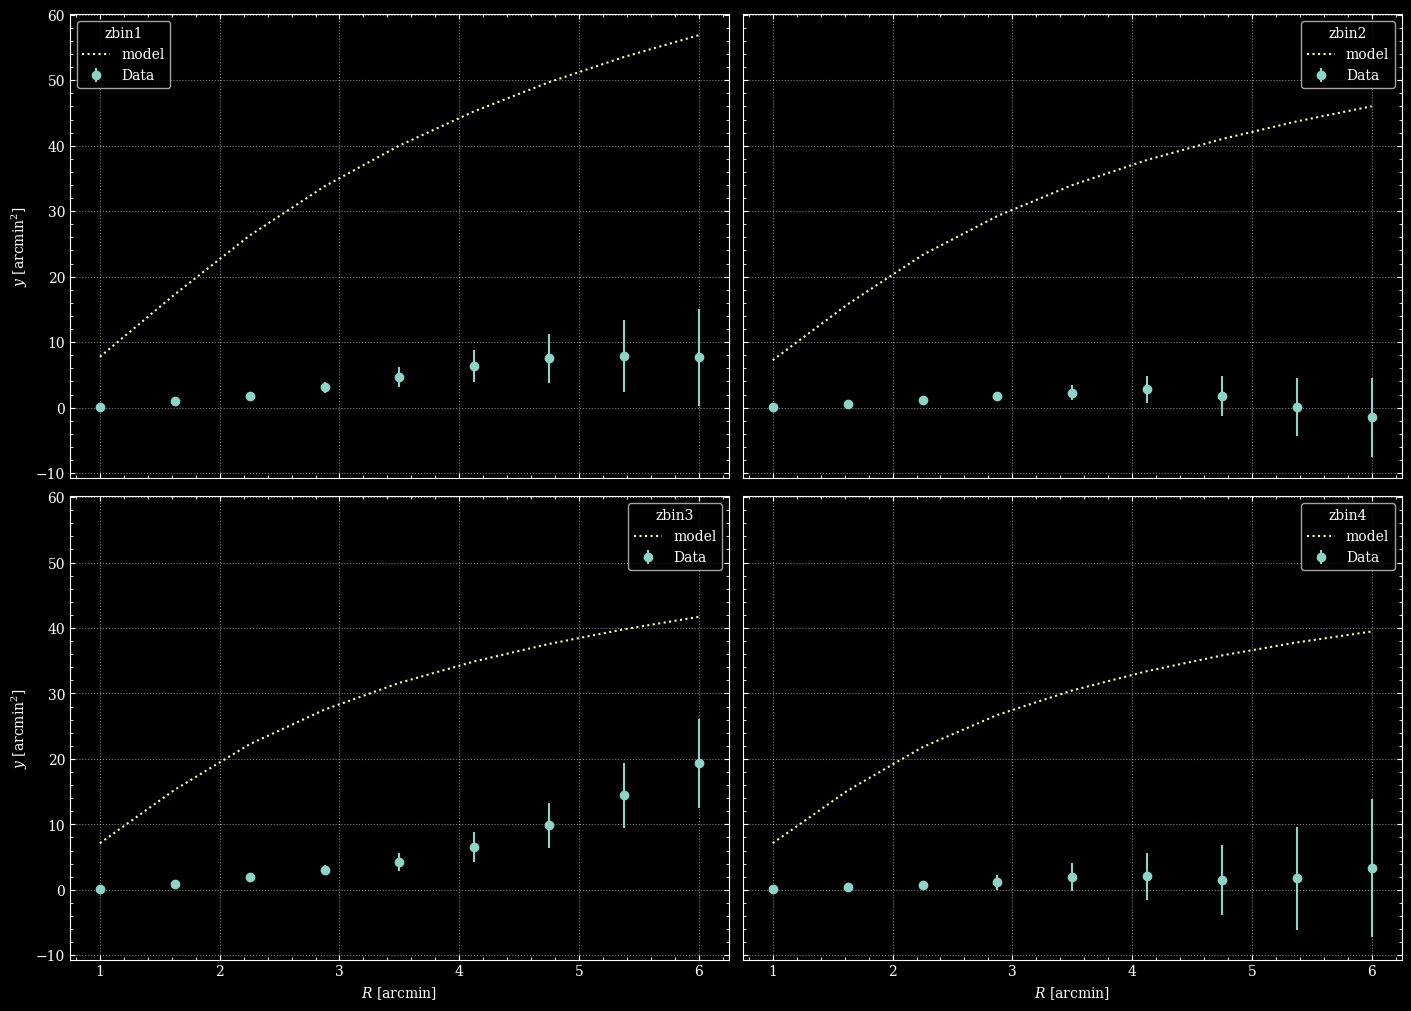

In [133]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
axs=axs.flatten()
for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    print
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.TkSZ_data, np.diag(model[likeli].meas.TkSZ_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(refparams), label='model', ls=':')
    ax.legend(title=likeli)
plt.show()

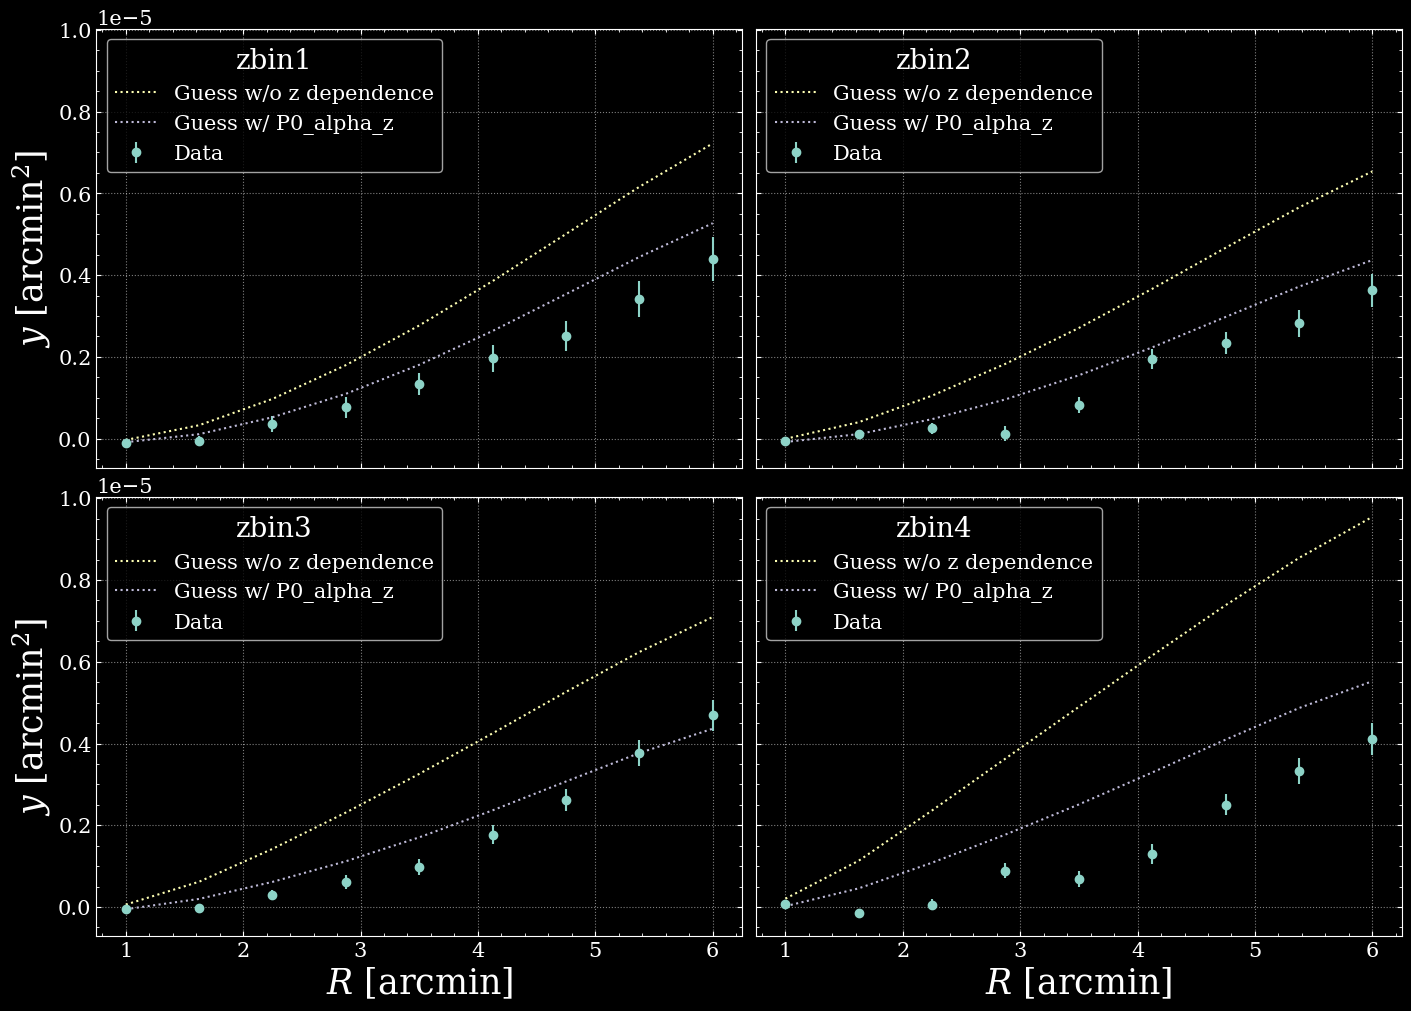

In [ ]:
pars01 = refparams | {'P0_alphaz':-0.8}
pars00= refparams | {'P0_alphaz':0}

fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
axs=axs.flatten()
for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
    print
    ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars00), label='Guess w/o z dependence', ls=':')
    ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars01), label='Guess w/ P0_alpha_z', ls=':')
    ax.legend(title=likeli)
plt.show()

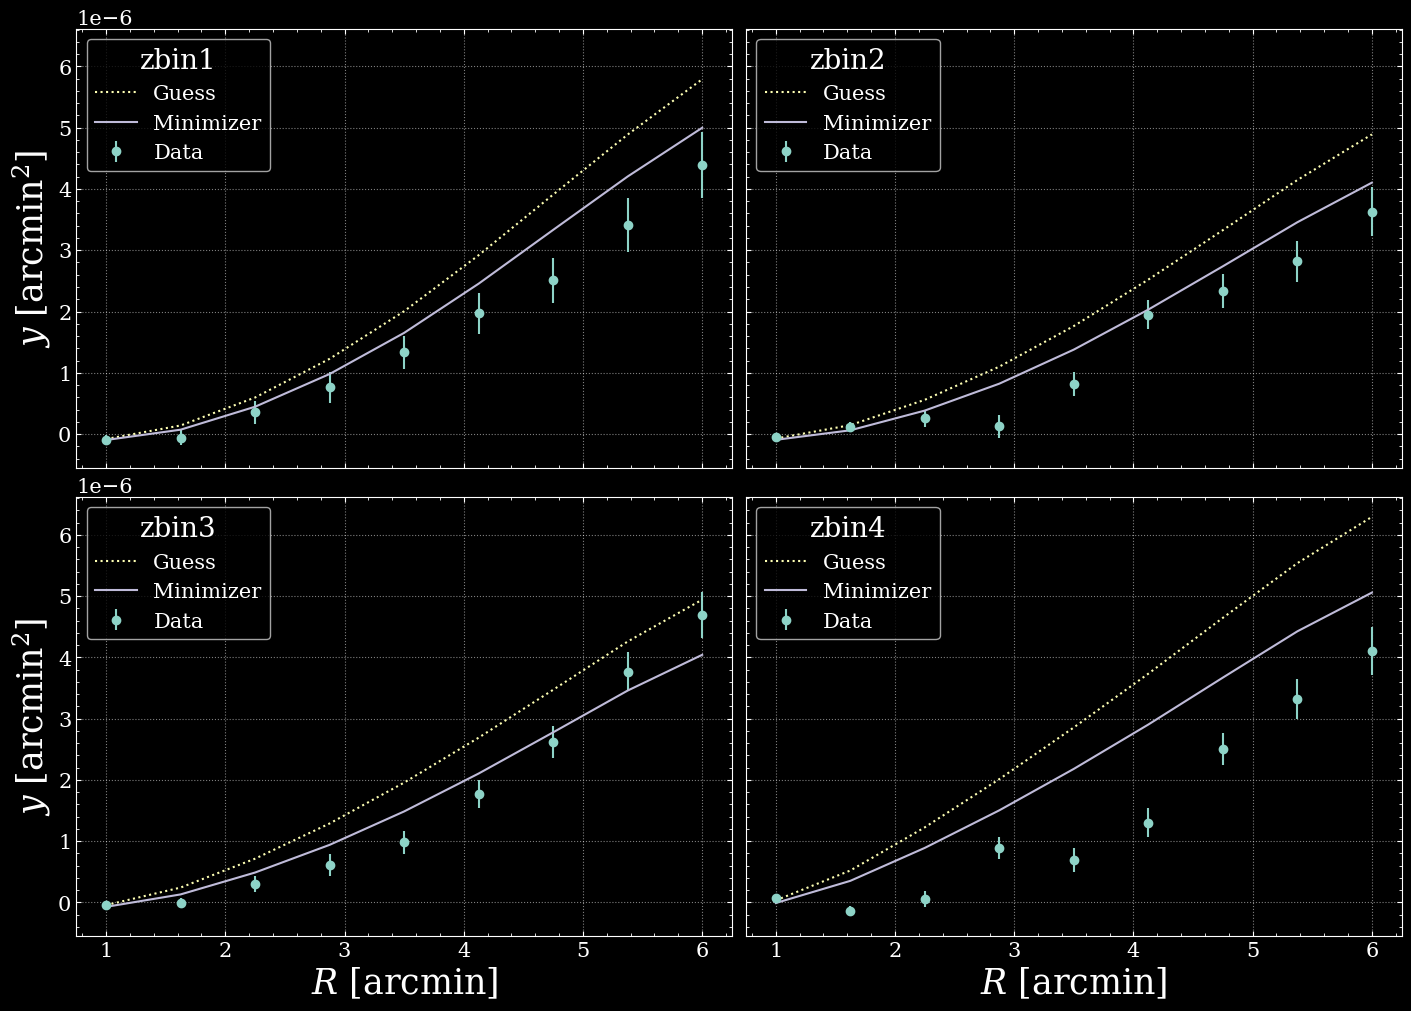

In [120]:
SOLikelihoods.YAML_FILE = "/global/homes/c/cpopik/CAPPIBARAS/chains/runchainsRiedGuachalla.yaml"

# Run a quick minimizer but change the output file so it doesn't overwrite the real one
yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()
yamlinfo_min["output"] = yamlinfo_min["output"] + "_minimizer"
updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, minimize=True, force=True)
# minimum = minimizer.products()["minimum"]
# parsfit = {k: minimum[k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}

# fig, axs = plt.subplots(2, 2, figsize=(14, 10), layout='constrained', sharex=True, sharey=True)
# axs=axs.flatten()
# for ax in [axs[0], axs[2]]: ax.set(ylabel=r'$y$ [arcmin$^2$]')
# for ax in [axs[2], axs[3]]: ax.set(xlabel=r'$R$ [arcmin]')
# for ax, likeli in zip(axs, yamlinfo['likelihood'].keys()):
#     ax.errorbar(model[likeli].meas.R, model[likeli].meas.y_data, np.diag(model[likeli].meas.y_cov)**0.5, marker='o', ls='', label='Data')
#     ax.plot(model[likeli].meas.R, model[likeli]._get_theory(pars0), label='Guess', ls=':')
#     ax.plot(model[likeli].meas.R, model[likeli]._get_theory(dict(minimum.MAP())), label='Minimizer')
#     ax.legend(title=likeli)
# plt.show()

# Pre-fit

In [223]:
# Reload modules to updates
importlib.reload(SOLikelihoods)

SOLikelihoods.YAML_FILE = "/global/homes/c/cpopik/CAPPIBARAS/chains/runchainsRiedGuachalla.yaml"
SOLikelihoods.VERBOSE = False

# Run a quick minimizer but change the output file so it doesn't overwrite the real one
yamlinfo_min = cobaya.yaml.yaml_load_file(SOLikelihoods.YAML_FILE).copy()
yamlinfo_min["output"] = yamlinfo_min["output"] + "_minimizer"
updated_info_minimizer, minimizer = cobaya.run(yamlinfo_min, minimize=True, force=True)

parsfit = {k: minimizer.products()["minimum"][k] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}
p0 = {k: v['ref'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v}
parslabel = [v['latex'] for k, v in yamlinfo_min['params'].items() if isinstance(v, dict) and "prior" in v]

likelis = list(minimizer.model.likelihood.keys())

INFO:output:Output to be read-from/written-into folder 'chains/RiedGuachalla2025', with prefix 'testing_theory_minimizer'


[output] Output to be read-from/written-into folder 'chains/RiedGuachalla2025', with prefix 'testing_theory_minimizer'


INFO:output:Found existing info files with the requested output prefix: 'chains/RiedGuachalla2025/testing_theory_minimizer'


[output] Found existing info files with the requested output prefix: 'chains/RiedGuachalla2025/testing_theory_minimizer'


INFO:output:Will delete previous products ('force' was requested).


...

[minimize] -log(posterior) minimized to 23.474


INFO:minimize:Parameter values at minimum:
   weight  minuslogpost   logrho0    beta_k     A2h_t  minuslogprior  minuslogprior__0       chi2  chi2__kSZ_RG25_z1  chi2__kSZ_RG25_z2  chi2__kSZ_RG25_z3  chi2__kSZ_RG25_z4
0     1.0     23.474019  1.788526  1.795068  1.063838       5.834811          5.834811  35.278416           6.974218           19.60051           1.821407           6.882281


[minimize] Parameter values at minimum:
   weight  minuslogpost   logrho0    beta_k     A2h_t  minuslogprior  minuslogprior__0       chi2  chi2__kSZ_RG25_z1  chi2__kSZ_RG25_z2  chi2__kSZ_RG25_z3  chi2__kSZ_RG25_z4
0     1.0     23.474019  1.788526  1.795068  1.063838       5.834811          5.834811  35.278416           6.974218           19.60051           1.821407           6.882281


INFO:minimize:Full set of minima:
{'0': (23.474018720917314, True), '1': (23.474018720917314, True)}


[minimize] Full set of minima:
{'0': (23.474018720917314, True), '1': (23.474018720917314, True)}


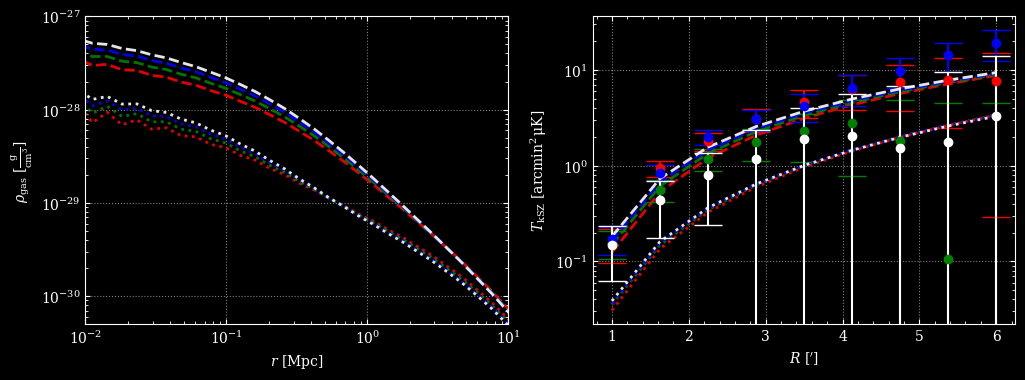

In [ ]:
importlib.reload(Plots); importlib.reload(Profiles)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].set(
    xlabel=r"$r$"+f" [{model.r.unit.to_string(format='latex')}]", ylabel=r"$\rho_\text{gas}$"+f" [{model.aveprof(p0).to(u.g/u.cm**3).unit.to_string(format='latex')}]",
    xlim=(1e-2, 1e1), ylim=(5e-31,1e-27))

axs[1].set(
    xlabel=r"$R$"+f" [{model.meas.R.unit.to_string(format='latex')}]", ylabel=r"$T_\text{kSZ}$"+f" [{model.meas.TkSZ_data.unit.to_string(format='latex')}]",
    yscale='log')

colors = ['r', 'g', 'b', 'w']

for likeli, c in zip(likelis, colors):

    model = minimizer.model.likelihood[likeli]

    axs[0].loglog(model.r, model.aveprof(p0).to(u.g/u.cm**3), ls=':', lw=2,c=c, alpha=0.9,label=f'guess {likeli}')
    axs[0].loglog(model.r, model.aveprof(parsfit).to(u.g/u.cm**3), ls='--', lw=2,alpha=0.9,c=c,label=f'fit {likeli}')

    axs[1].errorbar(model.meas.R, model.meas.TkSZ_data, model.meas.TkSZ_err,c=c,label=f'data {likeli}', marker='o', capsize=10, ls='None')
    axs[1].plot(model.meas.R, model._get_theory(p0), ls=':', lw=2,c=c,alpha=0.9,label=f'guess {likeli}')
    axs[1].plot(model.meas.R, model._get_theory(parsfit), ls='--', lw=2,c=c,alpha=0.9,label=f'fit {likeli}')

# axs[0].legend(fontsize); axs[1].legend()
plt.show()